In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

import torch
from torchvision import datasets, transforms


In [4]:
DATASET_DIR = r"D:\Rakib\final\data\Brain Cancer" 

# List classes
classes = sorted(os.listdir(DATASET_DIR))
num_classes = len(classes)

print("Total classes:", num_classes)
print("Sample classes:", classes[:7])


Total classes: 44
Sample classes: ['Astrocitoma T1', 'Astrocitoma T1C+', 'Astrocitoma T2', 'Carcinoma T1', 'Carcinoma T1C+', 'Carcinoma T2', 'Ependimoma T1']


In [14]:
class_counts = {}

for cls in classes:
    cls_path = os.path.join(DATASET_DIR, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    class_counts[cls] = len(images)

# Convert to DataFrame
df_counts = pd.DataFrame.from_dict(class_counts, orient='index', columns=['Image_Count'])
df_counts = df_counts.sort_values(by='Image_Count', ascending=False)

df_counts.num_classes = len(classes)
print("\n Class distribution: \n", df_counts)




 Class distribution: 
                         Image_Count
Meningioma T1C+                 369
Meningioma T1                   272
_NORMAL T2                      271
_NORMAL T1                      251
Meningioma T2                   233
Astrocitoma T1C+                232
Neurocitoma T1C+                223
Schwannoma T1C+                 194
Astrocitoma T1                  176
Astrocitoma T2                  171
Schwannoma T1                   148
Neurocitoma T1                  130
Schwannoma T2                   123
Carcinoma T1C+                  112
Papiloma T1C+                   108
Neurocitoma T2                  104
Glioblastoma T1C+                94
Oligodendroglioma T1             86
Tuberculoma T1C+                 84
Carcinoma T2                     73
Oligodendroglioma T1C+           72
Meduloblastoma T1C+              67
Papiloma T1                      66
Oligodendroglioma T2             66
Carcinoma T1                     66
Papiloma T2                      63
Epen

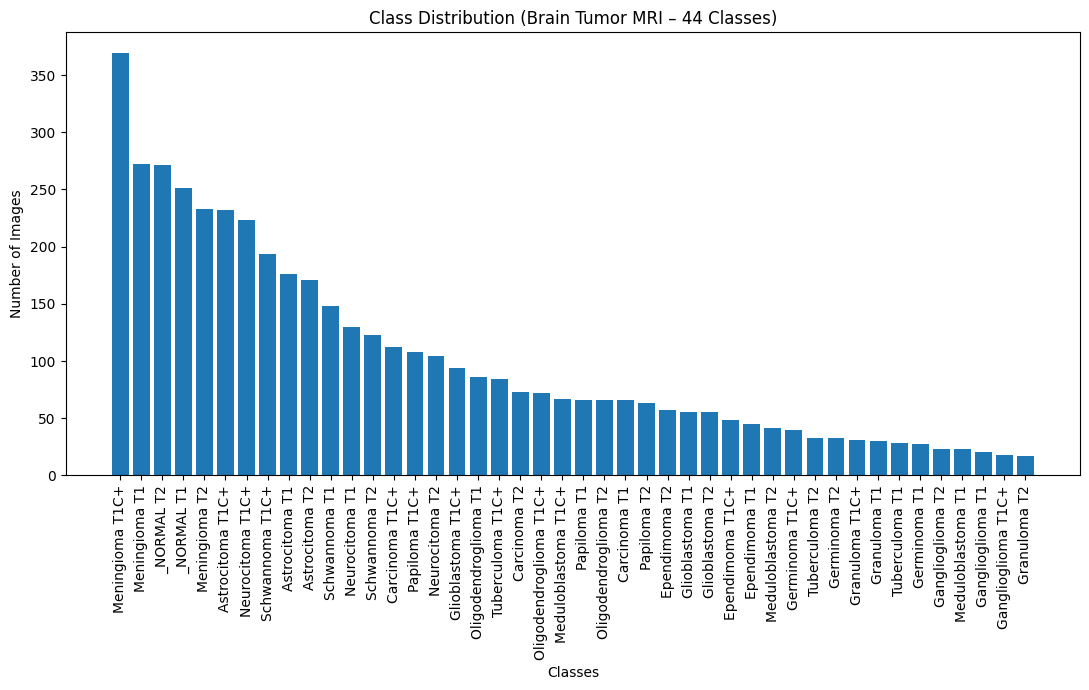

In [17]:
plt.figure(figsize=(11,7))
plt.bar(df_counts.index, df_counts['Image_Count'])
plt.xticks(rotation=90)
plt.title("Class Distribution (Brain Tumor MRI – 44 Classes)")
plt.ylabel("Number of Images")
plt.xlabel("Classes")
plt.tight_layout()
plt.show()


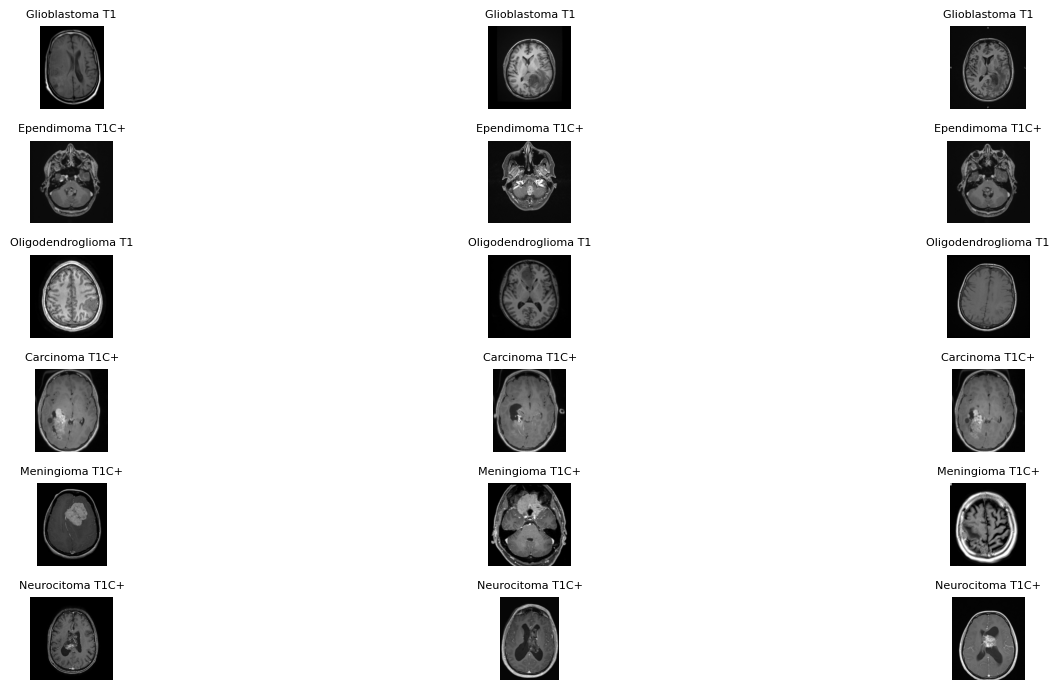

In [21]:
def show_sample_images(dataset_dir, classes, samples_per_class=3):
    plt.figure(figsize=(17,7))
    idx = 1

    for cls in random.sample(classes, 6):  # visualize 6 random classes
        cls_path = os.path.join(dataset_dir, cls)
        images = random.sample(os.listdir(cls_path), samples_per_class)

        for img_name in images:
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path).convert("RGB")

            plt.subplot(6, samples_per_class, idx)
            plt.imshow(img)
            plt.axis("off")
            plt.title(cls, fontsize=8)
            idx += 1

    plt.tight_layout()
    plt.show()

show_sample_images(DATASET_DIR, classes)


In [22]:
widths, heights, aspect_ratios = [], [], []

for cls in classes:
    cls_path = os.path.join(DATASET_DIR, cls)
    for img_name in os.listdir(cls_path)[:30]:  # limit for speed
        img = Image.open(os.path.join(cls_path, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h)


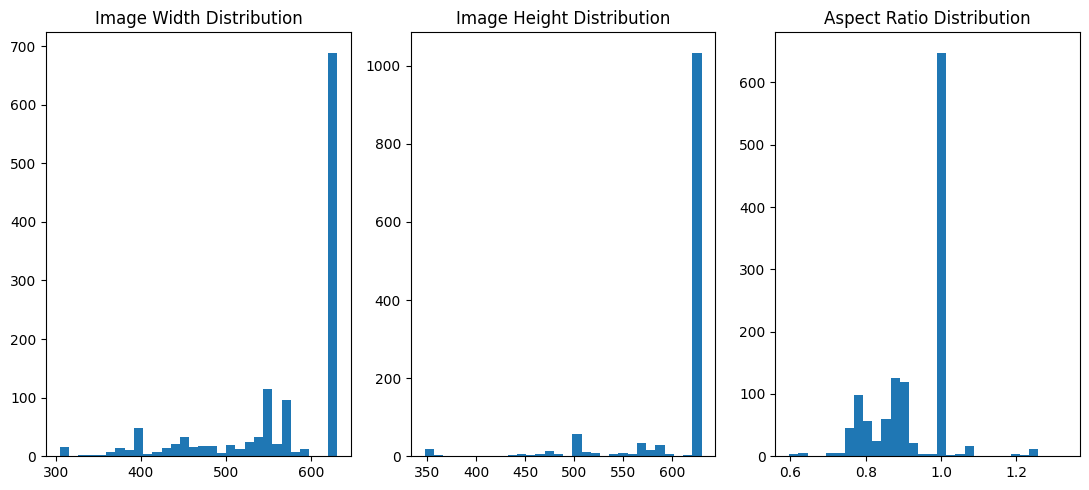

In [25]:
plt.figure(figsize=(11,5))

plt.subplot(1,3,1)
plt.hist(widths, bins=30)
plt.title("Image Width Distribution")

plt.subplot(1,3,2)
plt.hist(heights, bins=30)
plt.title("Image Height Distribution")

plt.subplot(1,3,3)
plt.hist(aspect_ratios, bins=30)
plt.title("Aspect Ratio Distribution")

plt.tight_layout()
plt.show()


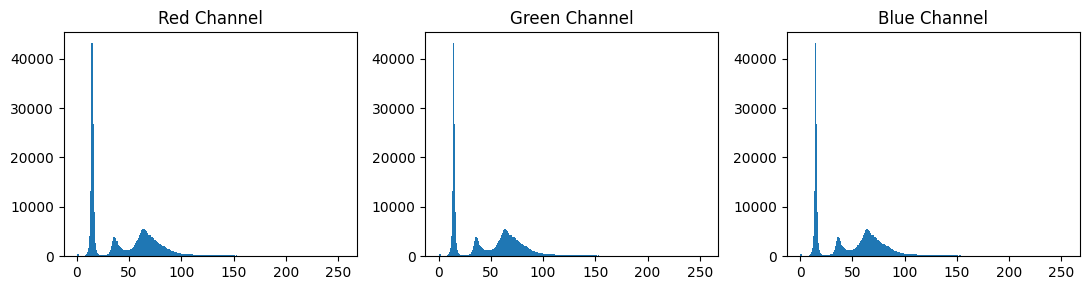

In [28]:
def plot_rgb_distribution(img_path):
    img = Image.open(img_path).convert("RGB")
    img_np = np.array(img)

    plt.figure(figsize=(11,3))
    colors = ['Red', 'Green', 'Blue']

    for i, col in enumerate(colors):
        plt.subplot(1,3,i+1)
        plt.hist(img_np[:,:,i].ravel(), bins=256)
        plt.title(f"{col} Channel")

    plt.tight_layout()
    plt.show()

# Random image
random_class = random.choice(classes)
random_image = random.choice(os.listdir(os.path.join(DATASET_DIR, random_class)))
plot_rgb_distribution(os.path.join(DATASET_DIR, random_class, random_image))


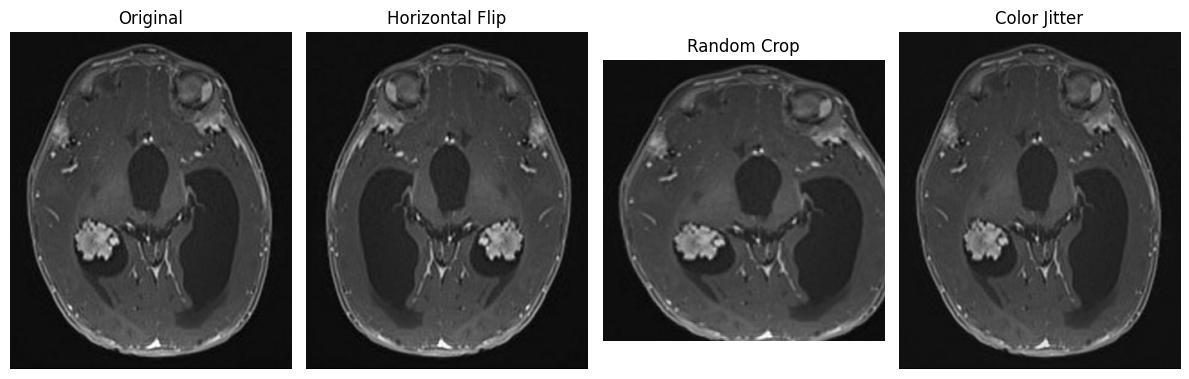

In [29]:
augmentation_transforms = {
    "Original": transforms.Compose([]),
    "Horizontal Flip": transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0)
    ]),
    "Random Crop": transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0))
    ]),
    "Color Jitter": transforms.Compose([
        transforms.ColorJitter(brightness=0.2, contrast=0.2)
    ])
}

img = Image.open(os.path.join(DATASET_DIR, random_class, random_image)).convert("RGB")

plt.figure(figsize=(12,4))
for i, (name, tfm) in enumerate(augmentation_transforms.items()):
    aug_img = tfm(img)
    plt.subplot(1,4,i+1)
    plt.imshow(aug_img)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()
